In [15]:
#Importation des bibliothèques
import numpy as np #importer la biblio numpy pour les calculs mathematiques
import pandas as pd #importer la biblio pandas pour la manipulation des DataFrames et des données
from sklearn import datasets #importer les datasets predefinis de sklearn
from sklearn.preprocessing import StandardScaler #pour la normalisation des données 
from sklearn.neighbors import KNeighborsClassifier #importer le modele KNN
from sklearn.metrics import accuracy_score,classification_report #importer les fonctions concernant l'accuracy et le rapport de classification de la biblio sklearn.metrics
from sklearn.model_selection import train_test_split #importer la fonction specialisee dans la sepration test et entrainement depuis la biblio sklearn.model_selection
from matplotlib import pyplot as plt #importer la bibliotheque matplotlib.pyplot pour la visualisation graphique

In [16]:
#Importation du jeu de données
iris=datasets.load_iris()
X=pd.DataFrame(iris.data,columns=iris.feature_names) #création du DataFrame du dataset Iris et le remplir
Y=pd.Series(iris.target,name="classe") #remplir ce DataFrame par les nom des classes des fleurs appartenant au datase Iris
X.head(),Y.head() #Affichage du DataFrame


(   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                5.1               3.5                1.4               0.2
 1                4.9               3.0                1.4               0.2
 2                4.7               3.2                1.3               0.2
 3                4.6               3.1                1.5               0.2
 4                5.0               3.6                1.4               0.2,
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: classe, dtype: int64)

In [17]:
#Exploration du jeu de données
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
#Séparation test/entrainement
(X_train,X_test,Y_train,Y_test)=train_test_split(X,Y,test_size=0.2,random_state=42) 
#choisir 20% des données pour le test et 80% pour l'entrainement 

In [19]:
#Normalisation des données
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train) #Normalisation des X pour l'entrainement
X_test_scaled=scaler.transform(X_test) #Normalisation des Y pour l'entrainement


In [20]:
#Entrainement du modele KNN
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled,Y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
#Prédiction
Y_pred=knn.predict(X_test_scaled)


In [22]:
#Vérification des prédictions
print("Accuracy:",accuracy_score(Y_test,Y_pred))
print("Classification report:")
print(classification_report(Y_test,Y_pred))

Accuracy: 1.0
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



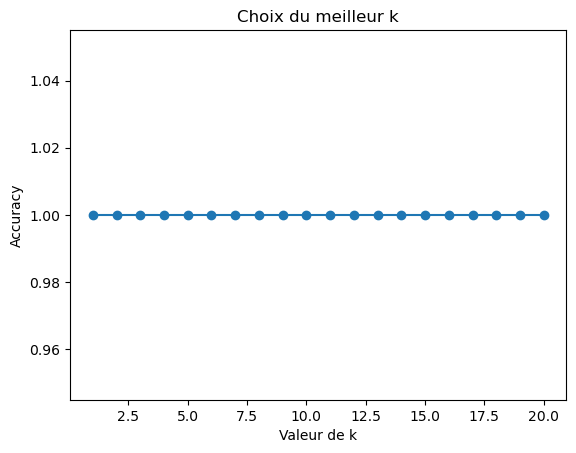

In [23]:
#Tester avec des valeurs de K
k_values=range(1,21)
accuracies=[]
for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled,Y_train)
    Y_pred=knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(Y_test,Y_pred))
plt.plot(k_values,accuracies,marker='o')
plt.xlabel("Valeur de k")
plt.ylabel("Accuracy")
plt.title("Choix du meilleur k")
plt.show()
    